In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv('steam_games_cleaned.csv')

In [3]:
df = df.drop(columns=['review_count','log_review_count'])

In [4]:
df = df.drop(columns=['review_sentiment'])

**Feature ENGG**

In [6]:
genre_dummies = df['genres'].str.get_dummies(',')

df = pd.concat([df, genre_dummies], axis=1)

df = df.drop(columns=['genres'])

In [7]:
current_year = 2026
df['game_age'] = current_year - df['release_year']

A new feature game_age was created to represent how long a game has been available since its release. Older games have had more time to accumulate user reviews, which may influence their popularity. This feature is calculated as the difference between the current year and the game's release year.

In [9]:
df['genre_count'] = genre_dummies.sum(axis=1)


The genre_count feature was introduced to capture the number of genres associated with each game. Games belonging to multiple genres may appeal to a broader audience, which could potentially increase player engagement and the number of reviews.

In [11]:
df['price_bucket'] = pd.cut(
    df['price'],
    bins=[-1,0,500,1000,2000,df['price'].max()+1],
    labels=['Free','Cheap','Mid','Premium','Expensive']
)

In [12]:
dev_freq = df['developer'].value_counts(normalize=True)

df['developer_freq'] = df['developer'].map(dev_freq)

pub_freq = df['publisher'].value_counts(normalize=True)

df['publisher_freq'] = df['publisher'].map(pub_freq)

In [22]:
df = df.drop(columns=['developer','publisher'])

In [24]:
df['price_bucket'] = pd.cut(
    df['price'],
    bins=[-1,0,500,1500,3000,10000],
    labels=['Free','Cheap','Mid','Expensive','Premium']
)

In [196]:
# df['score_bucket'] = pd.cut(
#     df['review_score'],
#     bins=[0,50,70,85,100],
#     labels=['Bad','Average','Good','Excellent']
# )

In [198]:
# df['release_season'] = (df['release_month'] % 12) // 3 + 1

In [26]:
df = df.drop(columns=['game_name'])

In [28]:
df = df.drop(columns=['release_year'])

In [68]:
df = df.drop(columns=['developer_freq','publisher_freq'])

In [70]:
df = df.drop(columns=['genre_count'])

In [72]:
df.columns 

Index(['price', 'release_month', 'review_score', 'popularity_tier', 'Action',
       'Adventure', 'Casual', 'Early Access', 'Free To Play', 'Indie',
       'Massively Multiplayer', 'RPG', 'Racing', 'Simulation', 'Sports',
       'Strategy', 'game_age', 'price_bucket'],
      dtype='object')

In [74]:
df['popularity_tier'].unique()

array([2, 3, 1, 0], dtype=int64)

In [76]:
df.head(5)


,price,release_month,review_score,popularity_tier,Action,Adventure,Casual,Early Access,Free To Play,Indie,Massively Multiplayer,RPG,Racing,Simulation,Sports,Strategy,game_age,price_bucket
0,1100.0,3,97,2,0,0,0,1,0,1,0,0,0,0,0,1,0,Mid
1,4399.0,2,96,3,1,1,0,0,0,0,0,0,0,0,0,0,0,Premium
2,0.0,8,86,3,1,0,0,0,1,0,0,0,0,0,0,0,14,Free
3,2449.0,3,90,2,1,0,0,0,0,0,0,0,0,0,0,0,0,Expensive
4,2467.0,10,86,3,1,0,0,0,0,0,0,0,0,0,0,0,1,Expensive


**Spliting Data**

,price,release_month,review_score,Action,Adventure,Casual,Early Access,Free To Play,Indie,Massively Multiplayer,RPG,Racing,Simulation,Sports,Strategy,game_age,price_bucket
0,1100.0,3,97,0,0,0,1,0,1,0,0,0,0,0,1,0,Mid
1,4399.0,2,96,1,1,0,0,0,0,0,0,0,0,0,0,0,Premium
2,0.0,8,86,1,0,0,0,1,0,0,0,0,0,0,0,14,Free
3,2449.0,3,90,1,0,0,0,0,0,0,0,0,0,0,0,0,Expensive
4,2467.0,10,86,1,0,0,0,0,0,0,0,0,0,0,0,1,Expensive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1959,880.0,2,89,1,0,0,0,0,1,1,0,0,0,0,0,0,Mid
1960,1100.0,2,88,0,1,0,0,0,1,0,1,0,0,0,0,2,Mid
1961,1499.0,3,89,0,0,0,0,0,0,0,0,0,0,0,1,17,Mid
1962,880.0,2,82,0,0,0,0,0,1,0,1,0,0,0,1,0,Mid


In [79]:
df.isnull().sum()

price                    0
release_month            0
review_score             0
popularity_tier          0
Action                   0
Adventure                0
Casual                   0
Early Access             0
Free To Play             0
Indie                    0
Massively Multiplayer    0
RPG                      0
Racing                   0
Simulation               0
Sports                   0
Strategy                 0
game_age                 0
price_bucket             1
dtype: int64

In [39]:
df['popularity_tier'].unique()

array(['High', 'Viral', 'Medium', 'Low'], dtype=object)

In [41]:
tier_map = {
    'Low':0,
    'Medium':1,
    'High':2,
    'Viral':3
}

df['popularity_tier'] = df['popularity_tier'].map(tier_map)

In [43]:
df['popularity_tier'].unique()

array([2, 3, 1, 0], dtype=int64)

In [45]:
X = df.drop(columns=['popularity_tier'])
y = df['popularity_tier']

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Encoding**

In [62]:
df['popularity_tier'].value_counts()

popularity_tier
2    491
3    491
1    491
0    491
Name: count, dtype: int64

In [66]:
X.describe()

,price,release_month,review_score,Action,Adventure,Casual,Early Access,Free To Play,Indie,Massively Multiplayer,RPG,Racing,Simulation,Sports,Strategy,game_age,genre_count,developer_freq,publisher_freq
count,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000
mean,1124.301426,6.606415,82.809572,0.510183,0.420570,0.177699,0.036151,0.039715,0.398167,0.060591,0.208758,0.033605,0.263238,0.030041,0.168024,4.049389,2.346741,0.758321,0.511935
std,1128.286731,3.611464,13.230293,0.500024,0.493776,0.382356,0.186713,0.195338,0.489645,0.238639,0.406524,0.180256,0.440503,0.170743,0.373983,4.034253,0.784097,0.289618,0.314243
min,0.000000,1.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003055,0.006619
25%,389.750000,3.000000,76.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.870163,0.031059
50%,770.000000,7.000000,86.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,3.000000,0.870163,0.711813
75%,1499.000000,10.000000,93.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,3.000000,0.870163,0.711813
max,10874.000000,12.000000,100.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,28.000000,3.000000,0.870163,0.711813


In [50]:
df.columns

Index(['price', 'release_month', 'review_score', 'popularity_tier', 'Action',
       'Adventure', 'Casual', 'Early Access', 'Free To Play', 'Indie',
       'Massively Multiplayer', 'RPG', 'Racing', 'Simulation', 'Sports',
       'Strategy', 'game_age', 'genre_count', 'price_bucket', 'developer_freq',
       'publisher_freq'],
      dtype='object')

In [52]:
cat_cols = ['price_bucket']

num_cols = [col for col in X.columns if col not in cat_cols]

In [54]:
cat_cols = ['price_bucket']

In [56]:
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

In [58]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=400, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=400, learning_rate=0.05),
    "XGBoost": XGBClassifier(n_estimators=400, learning_rate=0.05, eval_metric='mlogloss')
}

In [60]:
for name, model in models.items():

    pipe = Pipeline([
        ('prep', preprocess),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)

    preds = pipe.predict(X_test)

    acc = accuracy_score(y_test, preds)

    print(f"{name} Accuracy: {acc:.3f}")

Random Forest Accuracy: 0.501
Gradient Boosting Accuracy: 0.504
XGBoost Accuracy: 0.483


In [38]:
pred = pipe.predict(X_test)

In [40]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.5038167938931297
              precision    recall  f1-score   support

           0       0.58      0.69      0.63        97
           1       0.36      0.34      0.35       101
           2       0.43      0.34      0.38        93
           3       0.60      0.64      0.62       102

    accuracy                           0.50       393
   macro avg       0.49      0.50      0.49       393
weighted avg       0.49      0.50      0.50       393



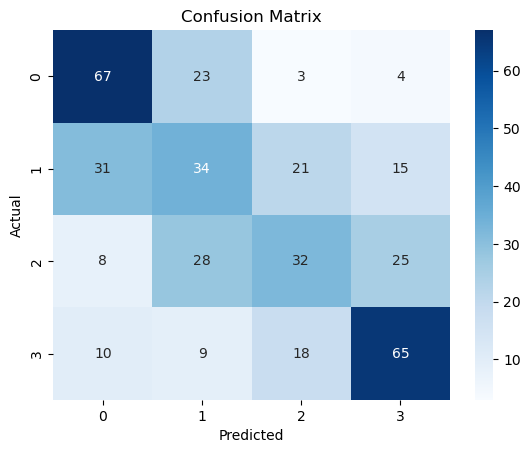

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()